In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

In [4]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

In [5]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


In [6]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


In [7]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


In [8]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


In [11]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [12]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [13]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


In [14]:
df_filled['Fav Friut'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart,Fav Friut
0,A,High School,15.000000,apple,36.0,apple
1,B,High School,17.000000,banana,41.0,banana
2,C,High School,15.857143,watermelon,37.5,watermelon
3,D,High School,16.000000,NaN,38.0,banana
4,E,Middle School,15.000000,banana,37.0,banana
5,F,Middle School,14.000000,grapes,37.5,grapes
6,G,Middle School,15.857143,mango,36.0,mango
7,H,High School,16.000000,papaya,39.0,papaya
8,I,High School,18.000000,NaN,40.0,banana
9,J,Middle School,15.857143,avocado,35.0,avocado


In [15]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


In [16]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


In [17]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [20]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


<Axes: ylabel='Height'>

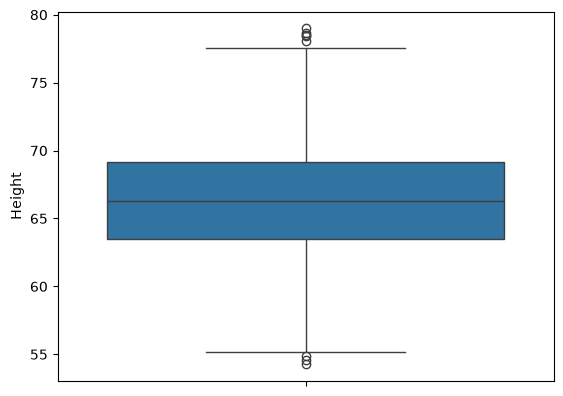

In [21]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

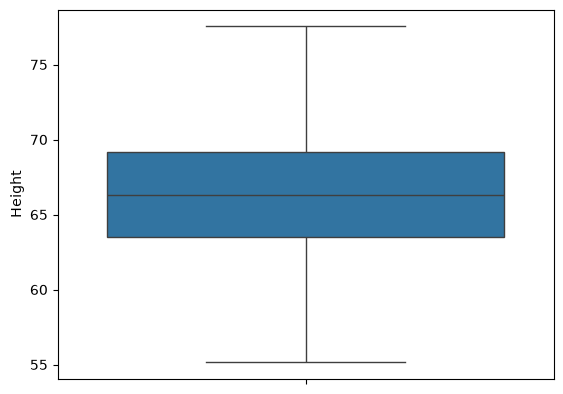

In [22]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
& (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])

<Axes: ylabel='Weight'>

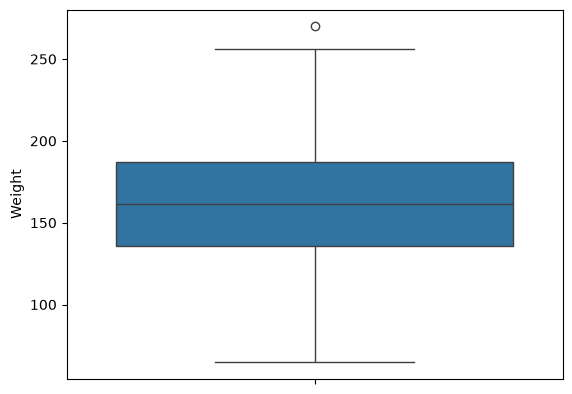

In [23]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

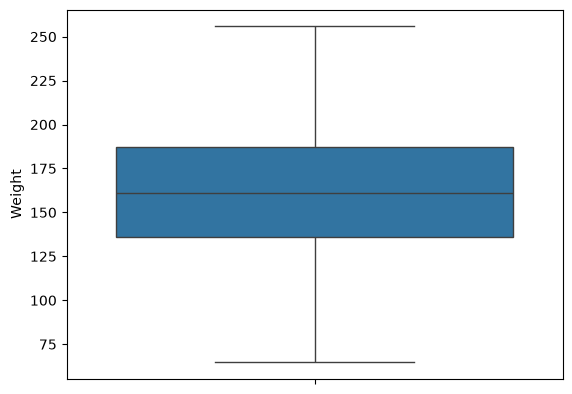

In [24]:

# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
& (df2['Weight'] <= upper_bound)]
sns.boxplot(clean_data['Weight'])

C:\Users\HP\AppData\Local\Temp\ipykernel_5492\3511842539.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_5492\3511842539.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


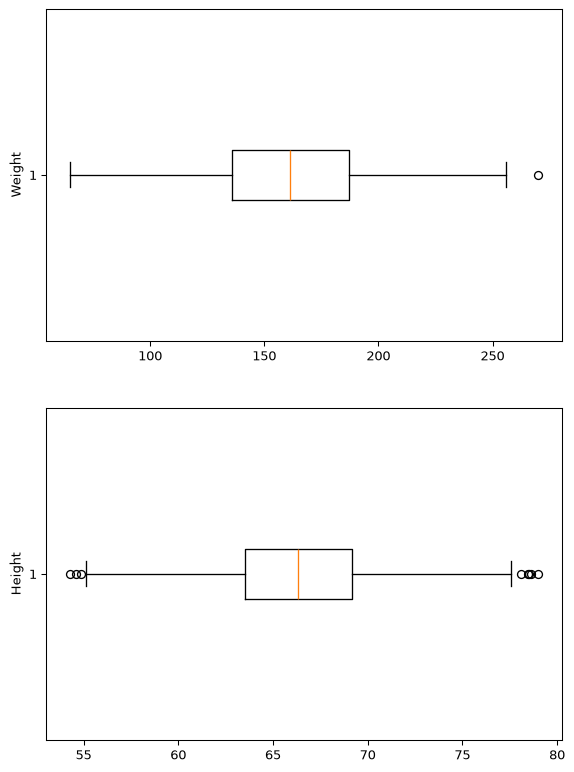

In [27]:
import matplotlib.pyplot as plt

# Membuat daftar kolom yang ingin dianalisis, yaitu "Weight" dan "Height".
columns_to_plot = ['Weight', 'Height']

# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]

# Membuat subplot
fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)

# Jika hanya ada satu kolom
if len(columns_to_plot) == 1:
    axs = [axs]

# Membuat boxplot
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df2[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_5492\1837013225.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_5492\1837013225.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


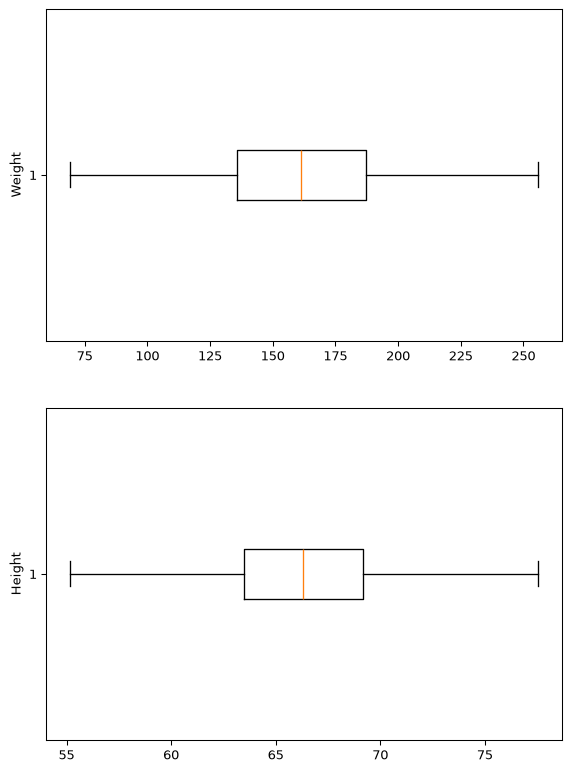

In [29]:
import numpy as np
import matplotlib.pyplot as plt
def remove_outliers_sequentially(df2, columns):
    df_cleaned = df2.copy()
    for col in columns:
        q1, q3 = np.percentile(df_cleaned[col], [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        df_cleaned = df_cleaned[
            (df_cleaned[col] >= lower_bound) &
            (df_cleaned[col] <= upper_bound)
        ]
    return df_cleaned
# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(
    df2,
    ['Height', 'Weight']
)
# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(clean_data[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

In [31]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.4 MB 2.6 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/8.4 MB 3.1 MB/s eta 0:00:03
   -------- ------------------------------- 1.8/8.4 MB 3.1 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.4 MB 4.0 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.4 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.4 MB 4.5 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.4 MB 5.2 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 4.9 MB/s  0:00:02

   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   -------- ------------------------------- 1/5 [narwhals]
   

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns # Ambil kolom
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns # Ambil k
rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [34]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)
# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


In [35]:
#Tugas Nomor 2
import pandas as pd
import numpy as np
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
#missing value
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [37]:
# Kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Kolom kategorikal
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

untuk dataset titanic, kita bisa menggunakan
1. kolom numerik -> isi missing dengan median
2. kolom kategorial -> isi missing value dengan modus

In [38]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [40]:
#Tugas nomor 3
diabetes = pd.read_csv("diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']

C:\Users\HP\AppData\Local\Temp\ipykernel_5492\3041875741.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_5492\3041875741.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)
C:\Users\HP\AppData\Local\Temp\ipykernel_5492\3041875741.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(diabetes[col], vert=False)


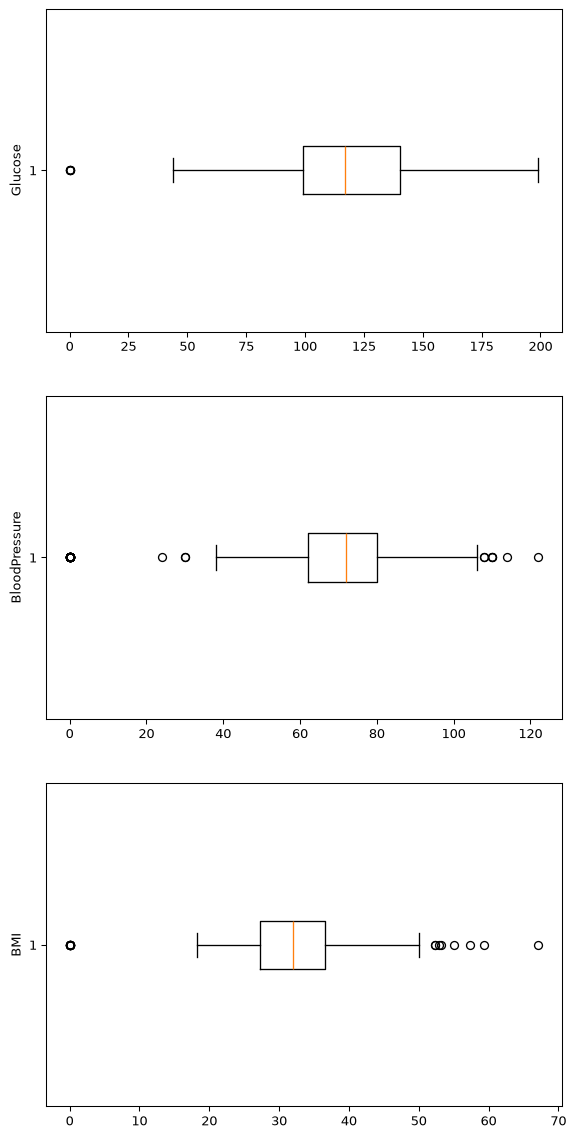

In [42]:
import matplotlib.pyplot as plt
fig,axs = plt.subplots(
    len(columns_to_plot),
    1,
    dpi=95,
    figsize=(7, 5 * len(columns_to_plot))
)
if len(columns_to_plot) == 1:
    axs = [axs]
for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(diabetes[col], vert=False)
    axs[i].set_ylabel(col)
plt.show()

In [43]:
#IQR
for col in columns_to_plot:
    q1 = diabetes[col].quantile(0.25)
    q3 = diabetes[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 - (1.5 * iqr)
    outliers = diabetes[
        (diabetes[col] < lower_bound) |
        (diabetes[col] > upper_bound)
    ]
    print(f"{col}: {len(outliers)} outliers")

Glucose: 735 outliers
BloodPressure: 731 outliers
BMI: 721 outliers


In [44]:
#hapus outliers
clean_diabetes = diabetes.copy()

for col in columns_to_plot:
    q1 = clean_diabetes[col].quantile(0.25)
    q3 = clean_diabetes[col].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    clean_diabetes = clean_diabetes[
        (clean_diabetes[col] >= lower_bound) &
        (clean_diabetes[col] <= upper_bound)
    ]